In [1]:
savecache=1
loadcache=0

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from ciceroscm import input_handler
import pandas as pd
from meteor import MeteorPatternScaling
from meteor import prpatt
from meteor import Cmip6MeteorDataGetter
import warnings
from pandas.errors import SettingWithCopyWarning
warnings.filterwarnings('ignore', category=FutureWarning) 
warnings.simplefilter(action='ignore', category=(SettingWithCopyWarning))
warnings.filterwarnings("ignore", message=".*not in pamset.*")


In [3]:
cscm_data_dir = os.path.join(os.getcwd(), "..", "src", "meteor", "default_scm_data")


Getting a datagetter to get CMIP6 data from the zarrstore for tas and pr

In [4]:
expts=["piControl", "abrupt-4xCO2", "historical","ssp585", "ssp245","ssp126"]
expts.index('historical')

2

In [5]:
flds = ["tas", "pr"]
data_getter = Cmip6MeteorDataGetter(exps=["piControl", "abrupt-4xCO2", "1pctCO2", "historical","ssp585", "ssp245","ssp126"], flds = flds, dbe=['CMIP','CMIP','CMIP','CMIP', 'ScenarioMIP','ScenarioMIP','ScenarioMIP'])
# This list now holds all the models with complete data for a single ensemble member for the given experiments and fields
models = data_getter.models
# For the purposes of this notebook we limit the use to looking at two coarse resolution models:
# 'ACCESS-ESM1-5',
models=['CanESM5']


Getting some data that can be used by the forcer engine and ciceroscm

In [6]:
%%capture
ih = input_handler.InputHandler({})
# NBVAL_IGNORE_OUTPUT

#For predictions: 
#read in SSP245 concentrations and emissions

scenarios = ["ssp126","ssp245","ssp585"]

conc_data=[]
em_data=[]
for i,s in enumerate(scenarios):
    conc_data.append(input_handler.read_inputfile(
    os.path.join(cscm_data_dir, s+"_conc_RCMIP.txt")
    ))

    em_data.append(ih.read_emissions(os.path.join(cscm_data_dir, s+"_em_RCMIP.txt")))

Getting training data to use for predictions:

In [7]:
if not loadcache:
    test_data={}
    for m in models:
        print(m)
        test_data[m] = {

            "base": data_getter.make_meteor_training_data("base", m), #control simulation
            "co2x4": data_getter.make_meteor_training_data("co2x4", m), #co2 only response
            "1pc": data_getter.make_meteor_training_data("1pc", m)} #co2 only response
            
        for s in scenarios:
                test_data[m][s]=data_getter.make_meteor_training_data_composite(
                        ["historical", s], m
                    )


CanESM5


In [8]:
if savecache:
    cachedir = os.path.join(os.getcwd(), "cache")
    if not os.path.exists(cachedir):
        os.makedirs(cachedir)
    for m in models:
        for k in test_data[m]:
            test_data[m][k].to_netcdf(
                os.path.join(cachedir, f"{m}_{k}_test_data.nc")
            )

In [9]:
if loadcache:
    cachedir = os.path.join(os.getcwd(), "cache")

    test_data={}
    for m in models:
        test_data[m] = {
            "base": xr.open_dataset(
                os.path.join(cachedir, f"{m}_base_test_data.nc")
            ),
            "co2x4": xr.open_dataset(
                os.path.join(cachedir, f"{m}_co2x4_test_data.nc")
            ),
            "1pc": xr.open_dataset(
                os.path.join(cachedir, f"{m}_1pc_test_data.nc")
            ),
        }
        for s in scenarios:
            test_data[m][s] = xr.open_dataset(
                os.path.join(cachedir, f"{m}_{s}_test_data.nc")
            )
        
        

Let's use SSP245 as the anomaly experiment

In [10]:
for m in models:
    test_data[m]["sulxanom"]=test_data[m]["ssp245"]

Making patterns one with just co2x4, and one including the sulfate from residual in the experiment. The fisrt will include just base (piControl) and co2x4 (abrupt4xCO2), the second will also have a sulxanom which we take from the historical and ssp245 composite experiment

First encode the pure CO2 response

In [11]:
%%capture
ghg_pattern = {}
for m in models:
    ghg_pattern[m] = MeteorPatternScaling(
            "cmip6-"+m+"-ghg",
            {"tas": 2, "pr": 2},
            lambda key: test_data[m][key],
            from_file=False,
            exp_list=["base", "co2x4"],
        )

Now encode a set of patterns, including the historical/future composite

In [12]:
%%capture
anomsulf_pattern = {}
for m in models:
    anomsulf_pattern[m] = MeteorPatternScaling(
            "cmip6-"+m+"-anomsulf",
            {"tas": 2, "pr": 2},
            lambda key: test_data[m][key],
            from_file=False,
            exp_list=["base", "co2x4", "sulxanom"],
        )

Then taking the data from the ssp-data for ciceroscm and making predictions

In [13]:
%%capture
patterns_ghg={}
patterns_anomsulf={}
for m in models:
    patterns_ghg[m]={}
    patterns_anomsulf[m]={}

    for i,s in enumerate(scenarios):
        patterns_ghg[m][s]=(ghg_pattern[m].predict_from_combined_experiment(
            em_data[i], conc_data[i], ["pr", "tas"])
        )
        patterns_anomsulf[m][s]=(anomsulf_pattern[m].predict_from_combined_experiment(
            em_data[i], conc_data[i], ["pr", "tas"])
        )

Plotting global means for the CMIP6 data, the pattern with all forcing as CO2, and the pattern from including the aerosol residual as obtained above

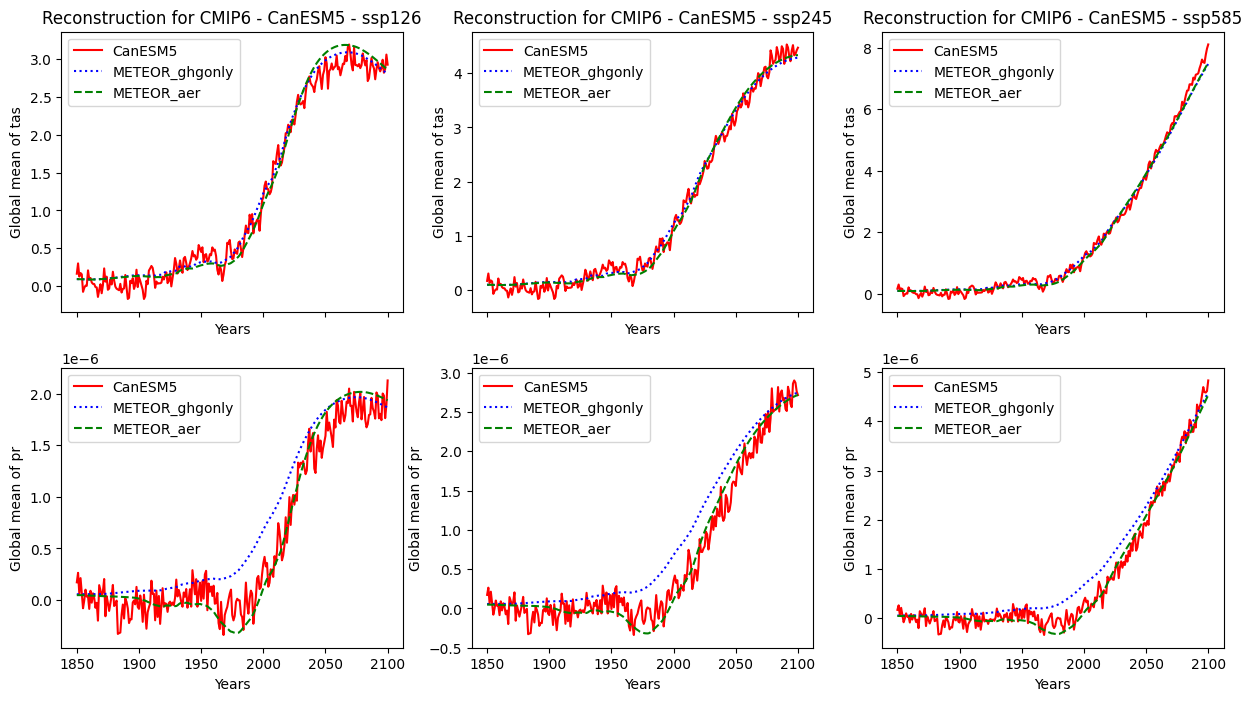

In [14]:
# NBVAL_IGNORE_OUTPUT
fig, axs = plt.subplots(nrows=len(flds), ncols=len(scenarios), sharex=True,figsize=(15,8))
m="CanESM5"
for i,s in enumerate(scenarios):
    for j, fld in enumerate(flds):
        zero_val = np.mean(prpatt.global_mean(test_data[m]["base"][fld]).values)
        total_years = len(test_data[m]["sulxanom"][fld]["year"].values)
        years_to_plot = range(1850,1850+total_years)
        axs[j,i].plot(years_to_plot, prpatt.global_mean(test_data[m][s][fld]).values[0,:]-zero_val, color="red", label=m)
        axs[j,i].plot(years_to_plot, prpatt.global_mean(patterns_ghg[m][s][fld]).values[100:], color="blue", label="METEOR_ghgonly",linestyle=':')
        axs[j,i].plot(years_to_plot, prpatt.global_mean(patterns_anomsulf[m][s][fld]).values[100:], color="green", label="METEOR_aer",linestyle='--')
        axs[j,i].set_xlabel("Years")
        if j == 0:
            axs[j,i].set_title(f"Reconstruction for CMIP6 - "+m+" - "+s)
        axs[j,i].set_ylabel(f"Global mean of {fld}")
        axs[j,i].legend()

In [15]:
test_data['CanESM5']['ssp245']['tas']

<xarray.DataArray 'tas' (ens: 1, year: 251, lat: 64, lon: 128)> Size: 16MB
array([[[[227.89488726, 227.58881773, 227.28518564, ..., 228.8498508 ,
          228.52827646, 228.20965513],
         [227.47526575, 226.76139204, 226.14248314, ..., 230.06016419,
          229.12434529, 228.25919382],
         [226.5846864 , 225.78897739, 225.17662642, ..., 230.35905774,
          228.90143199, 227.65157295],
         ...,
         [256.23454448, 256.6132667 , 256.94850276, ..., 255.05095127,
          255.42777104, 255.82193587],
         [255.55175689, 255.6676451 , 255.78064864, ..., 254.95882978,
          255.17643617, 255.38727517],
         [254.65801563, 254.67711679, 254.70944226, ..., 254.60833736,
          254.62079714, 254.63685646]],

        [[227.67177412, 227.39177029, 227.1223336 , ..., 228.56103223,
          228.25914879, 227.95829288],
         [227.15214129, 226.47222528, 225.89666919, ..., 229.71048918,
          228.76299673, 227.91421036],
         [226.19934697, 225.40794657, 224.87330071, ..., 229.8760728 ,
          228.4318657 , 227.2087011 ],
...
         [273.16446801, 273.74296064, 274.42003885, ..., 271.13779422,
          271.8273486 , 272.51580175],
         [272.72828846, 272.98527004, 273.18786086, ..., 271.86372915,
          272.14635085, 272.44791987],
         [273.18073998, 273.22644327, 273.26452737, ..., 273.03668756,
          273.08643088, 273.12766138]],

        [[234.33527815, 234.04505557, 233.77104923, ..., 235.22778032,
          234.91794555, 234.62718013],
         [234.22438509, 233.60764825, 233.06854716, ..., 236.60098877,
          235.72896637, 234.93198794],
         [233.81552805, 233.20726185, 232.72178428, ..., 236.9263975 ,
          235.66410669, 234.61387551],
         ...,
         [271.60253028, 272.34922644, 273.17013525, ..., 269.6146675 ,
          270.26711693, 270.9298732 ],
         [271.29486753, 271.60829317, 271.93216536, ..., 270.2546023 ,
          270.58743637, 270.95854108],
         [272.28183468, 272.36903051, 272.44658228, ..., 272.00884124,
          272.10682691, 272.18375687]]]])
Coordinates:
  * ens      (ens) int64 8B 1
    height   float64 8B 2.0
  * lat      (lat) float64 512B -87.86 -85.1 -82.31 -79.53 ... 82.31 85.1 87.86
  * lon      (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 348.8 351.6 354.4 357.2
  * year     (year) int64 2kB 0 1 2 3 4 5 6 7 ... 244 245 246 247 248 249 250

In [ ]:
monthly_data = data_getter.make_meteor_training_data_composite(
                        ["historical", 'ssp245'], 'CanESM5', monthly=True)
monthly_data


In [ ]:
ds=monthly_data
t_globm=ds['tas'].mean(dim=['lat','lon','ens'])
t_globm=t_globm-t_globm[:500].mean()


In [242]:
t_glob = t_globm.rolling(month=60, center=True).mean().interpolate_na('month',method='nearest',fill_value="extrapolate").values


In [172]:
from sklearn.linear_model import LinearRegression
time=ds['month'].values
# ---
## 📈 Part 1: Modulated Harmonic Regression for Seasonal Cycle

# We need to create a "design matrix" (X) for the regression.
# Features: intercept, T_glob, sin/cos for annual & semi-annual, and interaction terms.

# Create harmonic features
months_per_year = 12
annual_cos = np.cos(2 * np.pi * time / months_per_year)
annual_sin = np.sin(2 * np.pi * time / months_per_year)
semiannual_cos = np.cos(4 * np.pi * time / months_per_year)
semiannual_sin = np.sin(4 * np.pi * time / months_per_year)

# Stack all features into the design matrix X (shape: n_time x n_features)
# We use T_glob * harmonic to create the interaction terms.
X = np.vstack([
    t_glob,
    annual_cos,
    annual_sin,
    semiannual_cos,
    semiannual_sin,
    t_glob * annual_cos,
    t_glob * annual_sin,
    t_glob * semiannual_cos,
    t_glob * semiannual_sin
]).T

# The temperature data needs to be flattened from (time, lat, lon) to (time, space)
# where space = lat * lon.

Y_xr = ds['tas'].mean(dim=['ens']).stack(space=('lat', 'lon'))
Y=Y_xr.data

# Fit a linear regression. Scikit-learn handles adding an intercept.
# This efficiently fits one model for each of the (n_lat * n_lon) grid cells at once.
model = LinearRegression(fit_intercept=True)
model.fit(X, Y)

# The model now contains all the coefficients (betas, alphas, gammas from our equation)
# model.intercept_ has shape (n_space,)
# model.coef_ has shape (n_space, n_features)

# Reconstruct the fitted seasonal cycle for all time
seasonal_cycle_fit = model.predict(X)

# Reshape both the fit and the residuals back to the original (time, lat, lon) grid
seasonal_cycle_fit_xr = xr.DataArray(
    seasonal_cycle_fit,
    coords=Y_xr.coords,
    dims=Y_xr.dims
).unstack('space')

anomalies = ds['tas'].mean(dim=['ens']) - seasonal_cycle_fit_xr
ds['anomalies'] = anomalies

print("\nSeasonal cycle extracted. Anomalies calculated.")
print("Example anomaly value at month=0, lat=0, lon=0:", ds['anomalies'].isel(month=0, lat=0, lon=0).item())
print("-" * 20)



Seasonal cycle extracted. Anomalies calculated.
Example anomaly value at month=0, lat=0, lon=0: -0.2881977230995574
--------------------


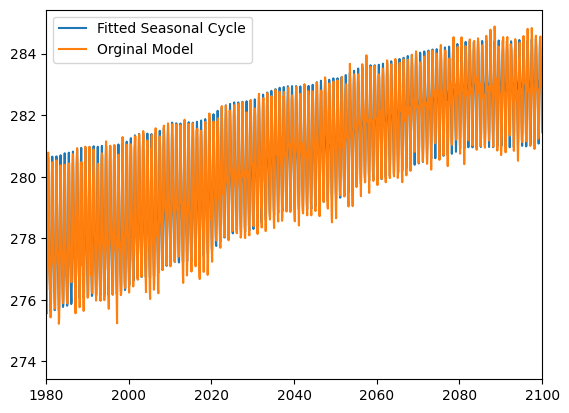

In [189]:
plt.plot(1850+ds['month']/12,seasonal_cycle_fit_xr.mean(dim=('lat','lon')), label='Fitted Seasonal Cycle')

plt.plot(1850+ds['month']/12,ds['tas'].mean(dim=('ens','lat','lon')), label='Orginal Model')
plt.xlim([1980, 2100])
plt.legend()

In [192]:
%pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 12.8 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [193]:
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from statsmodels.tsa.api import VAR
# ---
## 🌀 Step 1: Standard PCA on Full Anomaly Dataset

# We need the anomaly data as a 2D numpy array (time, space)
anomalies_flat = ds['anomalies'].stack(space=('lat', 'lon')).data

# Initialize and fit the PCA model
n_modes = 10  # Let's retain the top 10 modes
pca = PCA(n_components=n_modes)
pcs = pca.fit_transform(anomalies_flat) # Principal Components (time series)
eofs = pca.components_                    # EOFs (spatial patterns)

print(f"✅ Step 1 complete: PCA performed.")
print(f"   - PC shape: {pcs.shape}")
print(f"   - EOF shape: {eofs.shape}")
print(f"   - Variance explained by {n_modes} modes: {pca.explained_variance_ratio_.sum():.2%}")
print("-" * 30)


✅ Step 1 complete: PCA performed.
   - PC shape: (3012, 10)
   - EOF shape: (10, 8192)
   - Variance explained by 10 modes: 50.48%
------------------------------


In [207]:

# ---
## 📈 Step 2: Fit the VARX Model to the PCs

# The PCs are our target variables (endogenous)
# T_glob and month are our drivers (exogenous)

# Create the exogenous variable matrix
# We reuse the harmonic terms to represent the month

# The VAR model from statsmodels
# endog = our PC time series
# exog = our external drivers
model_var = VAR(endog=pcs, exog=X[:,:3])

# Fit the model. We must choose a lag order. For a demo, L=2 is fine.
# In a real study, you'd use model_var.select_order() to find the best lag.
lag_order = 2
results = model_var.fit(lag_order)

print(f"✅ Step 2 complete: VARX(2) model fitted to the {n_modes} PC time series.")
# Uncomment the line below to see a detailed statistical summary of the fit
# print(results.summary())
print("-" * 30)



✅ Step 2 complete: VARX(2) model fitted to the 10 PC time series.
------------------------------


In [240]:


# ---
## 🎲 Step 3: Simulate an Alternative Realisation (CORRECTED)

# We will build the new time series step-by-step in a loop.
n_time=pcs.shape[0]
n_simulation = n_time
synthetic_pcs = np.zeros_like(pcs)

# Use the historical data for the initial `lag_order` steps.
synthetic_pcs[:lag_order] = pcs[:lag_order]

# Get the covariance of the model's residuals (the "shocks")
# This is the key to generating new random behavior.
residual_cov = results.sigma_u
mean_shock = np.zeros(n_modes)

X_var=X[:n_simulation,:3]
# Loop from the first prediction point to the end
for t in range(lag_order, n_simulation):
    # 1. Get the inputs for the forecast
    current_initial_conditions = synthetic_pcs[t-lag_order:t]
    current_exog = X_var[t:t+1] # Must be 2D
    
    # 2. Get the deterministic forecast (the mean prediction)
    mean_forecast = results.forecast(y=current_initial_conditions, steps=1, exog_future=current_exog)
    
    # 3. Create a new random shock
    random_shock = np.random.multivariate_normal(mean_shock, residual_cov)
    
    # 4. Add the shock to the mean forecast to get the new stochastic value
    synthetic_pcs[t] = mean_forecast + random_shock


# Reconstruct the anomalies by multiplying the synthetic PCs by the EOFs
# This is the inverse of the PCA transformation
reconstructed_anomalies_flat = synthetic_pcs @ eofs

# Reshape the data back to the original grid (time, lat, lon)
# We can create a new xarray DataArray for this
reconstructed_anomalies_xr = xr.DataArray(
    reconstructed_anomalies_flat.reshape(n_time, len(ds['lat']), len(ds['lon'])),
    coords={
        "time": ds.coords['month'],
        "lat": ds.coords['lat'],
        "lon": ds.coords['lon']
    },
    dims=("month", "lat", "lon")
)


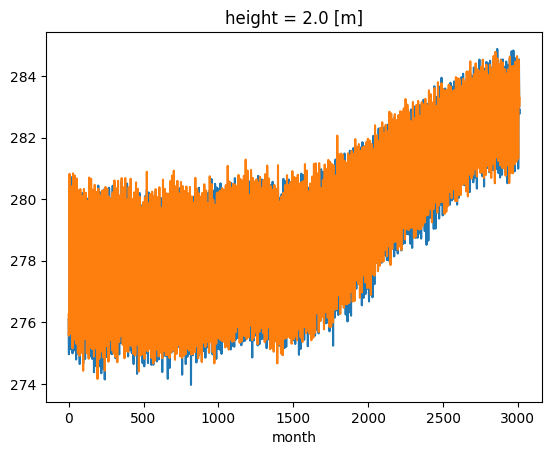

In [241]:
(ds['tas']).mean(dim=('lat','lon')).plot(label='Original anomalies')
(reconstructed_anomalies_xr + seasonal_cycle_fit_xr).mean(dim=('lat','lon')).plot(label='Reconstructed anomalies')